# Goal - How fingerprint changes across browser versions for the same device

Explanation:
-  fingerprint_per_version = unique_fingerprints / browser_versions tested
-  notatka - do finalnej analizy wezmę reprezentację paru kombinacji (os + os_version + browser) takich, które mają sensowną ilość wersji przeglądarek. Dlatego że dokładniejsze wyniki są, tam gdzie przetestowałem na przekroju 30 wersji przeglądarek niż np. 2 wersji.

In [117]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import hashlib

In [118]:
source_df = pd.read_parquet('2_after_feature_extraction/feature_matrix_media_calc.parquet')

In [119]:
# Remove rows that have no browser version
df = source_df[source_df['browserstack:browser_version'] != 'unknown']

# remove two columns: css:viewport_height and css:viewport_width
# because they change the distinction of fingerprints, because browserstack
# sometimes for the same device uses different viewport sizes
df = df.drop(columns=['css:viewport_height', 'css:viewport_width'])

# remove user agent from the mix
df = df[df.columns[~df.columns.str.contains('User-Agent')]]
df.shape

(763, 139)

In [120]:
# version with viewport sizes
# device_cols = ['browserstack:os', 'browserstack:os_version', 'browserstack:real_height', 'browserstack:real_width', 'browserstack:browser']

# version without viewport sizes
device_cols = ['browserstack:os', 'browserstack:os_version', 'browserstack:browser']
fingerprint_cols = [col for col in df.columns if col.startswith('css:')]

In [121]:
df['device_id'] = df[device_cols].astype(str).agg('-'.join, axis=1)

In [122]:
# Count how many browser versions per device
device_version_counts = df.groupby('device_id')['browserstack:browser_version'].nunique()
device_version_counts

device_id
OS X-Big Sur-chrome         29
OS X-Big Sur-edge           30
OS X-Big Sur-firefox        28
OS X-Catalina-chrome        23
OS X-Catalina-edge          18
OS X-Catalina-firefox       27
OS X-High Sierra-chrome     12
OS X-High Sierra-edge       11
OS X-High Sierra-firefox     6
OS X-Mojave-chrome          12
OS X-Mojave-edge            12
OS X-Mojave-firefox          4
OS X-Monterey-chrome        27
OS X-Monterey-edge          30
OS X-Monterey-firefox       24
OS X-Sequoia-chrome         25
OS X-Sequoia-edge           25
OS X-Sequoia-firefox        26
OS X-Sequoia-safari          1
OS X-Sierra-firefox          5
OS X-Sonoma-chrome          30
OS X-Sonoma-edge            31
OS X-Sonoma-firefox         24
OS X-Sonoma-safari           1
OS X-Ventura-chrome         30
OS X-Ventura-edge           28
OS X-Ventura-firefox        28
OS X-Ventura-safari          1
Windows-10-chrome           29
Windows-10-edge             28
Windows-10-firefox          28
Windows-11-chrome           2

In [123]:
multi_version_devices = device_version_counts[device_version_counts > 1].index

print(f"Found {len(multi_version_devices)} devices tested with multiple browser versions.")

Found 40 devices tested with multiple browser versions.


In [124]:
df_multi = df[df['device_id'].isin(multi_version_devices)].copy()

In [125]:
# compute md5 hash of the fingerprint values
df_multi['fingerprint'] = df_multi[fingerprint_cols].astype(str).agg('|'.join, axis=1).apply(lambda x: hashlib.md5(x.encode()).hexdigest())

In [126]:
fp_counts = df_multi.groupby('device_id')['fingerprint'].nunique()
version_counts = df_multi.groupby('device_id')['browserstack:browser_version'].nunique()

In [127]:
results = pd.DataFrame({
    'unique_fingerprints': fp_counts,
    'browser_versions': version_counts
})
results['fingerprint_per_version'] = results['unique_fingerprints'] / results['browser_versions']

print("\\nSummary of fingerprint variation across versions (same device):")
print(results.describe())

\nSummary of fingerprint variation across versions (same device):
       unique_fingerprints  browser_versions  fingerprint_per_version
count            40.000000         40.000000                40.000000
mean              5.225000         19.000000                 0.326130
std               2.475392         10.607206                 0.180905
min               1.000000          3.000000                 0.193548
25%               4.000000          6.000000                 0.200000
50%               5.500000         24.500000                 0.262963
75%               7.250000         28.000000                 0.333333
max               9.000000         31.000000                 1.000000


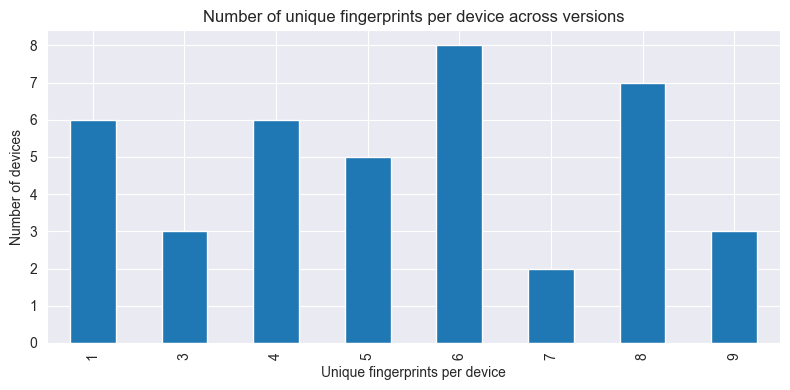

In [128]:
plt.figure(figsize=(8, 4))
results['unique_fingerprints'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of unique fingerprints per device across versions')
plt.xlabel('Unique fingerprints per device')
plt.ylabel('Number of devices')
plt.tight_layout()
plt.show()

In [129]:
changed = results[results['unique_fingerprints'] > 1]
print(f"\nOut of {len(results)} devices with multiple versions,")
print(f"{len(changed)} devices ({len(changed)/len(results)*100:.2f}%) had fingerprint changes across versions.")



Out of 40 devices with multiple versions,
34 devices (85.00%) had fingerprint changes across versions.


In [133]:
# example_id = changed.index[0]
example_id = 'Windows-7-chrome'
example_df = df_multi[df_multi['device_id'] == example_id][['browserstack:browser_version', 'fingerprint'] + fingerprint_cols]
example_df = example_df.sort_values('browserstack:browser_version')
print(f"Example device_id: {example_id}")
display(example_df[['browserstack:browser_version', 'fingerprint']])

Example device_id: Windows-7-chrome


,browserstack:browser_version,fingerprint
785,105.0,78d53d503036a603cc57d45126302e01
6,106.0,78d53d503036a603cc57d45126302e01
759,107.0,78d53d503036a603cc57d45126302e01
569,108.0,78d53d503036a603cc57d45126302e01
170,109.0,78d53d503036a603cc57d45126302e01


In [134]:
# devices without changes
results

,unique_fingerprints,browser_versions,fingerprint_per_version
device_id,,,
OS X-Big Sur-chrome,6,29,0.206897
OS X-Big Sur-edge,6,30,0.200000
OS X-Big Sur-firefox,8,28,0.285714
OS X-Catalina-chrome,5,23,0.217391
OS X-Catalina-edge,5,18,0.277778
OS X-Catalina-firefox,7,27,0.259259
OS X-High Sierra-chrome,4,12,0.333333
OS X-High Sierra-edge,5,11,0.454545
OS X-High Sierra-firefox,4,6,0.666667


In [132]:
filtered_df = df.filter(like='viewport', axis=1)
filtered_df

""
0
1
2
3
5
...
917
918
919
920
